### Gerekli Kütüphaneleri Import Etme

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


### Veri Setini Yükleme

In [2]:
df = pd.read_csv("sales_forecast_data.csv")

### EDA

In [3]:
print(f"Gözlem sayısı: {df.shape[0]}")
print(f"Sütun sayısı: {df.shape[1]}")

Gözlem sayısı: 36
Sütun sayısı: 5


In [4]:
print(f"Veri setinin ilk 5 satırı:\n{df.head()}")

Veri setinin ilk 5 satırı:
         date         sales  marketing_spend  num_customers  discount_rate
0  2022-01-01   9602.000000          2727.78            369           0.18
1  2022-02-01  11585.000000          2164.92            450           0.28
2  2022-03-01  13258.076211          3447.41            403           0.20
3  2022-04-01  13220.000000          1557.98            370           0.27
4  2022-05-01  12804.076211          2168.58            314           0.26


In [5]:
print(f"Veri setinde sütun bazında boş hücre sayısı {df.isna().sum()}")

Veri setinde sütun bazında boş hücre sayısı date               0
sales              0
marketing_spend    4
num_customers      0
discount_rate      0
dtype: int64


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             36 non-null     str    
 1   sales            36 non-null     float64
 2   marketing_spend  32 non-null     float64
 3   num_customers    36 non-null     int64  
 4   discount_rate    36 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.5 KB
None


In [7]:
print(df.describe())

              sales  marketing_spend  num_customers  discount_rate
count     36.000000        32.000000      36.000000      36.000000
mean   12508.083333      2974.718437     283.777778       0.164167
std     2371.253191      1220.586283     137.581791       0.081744
min     7971.000000      1137.550000      -1.000000       0.010000
25%    10977.730947      1976.015000     176.000000       0.102500
50%    12482.500000      2902.495000     309.500000       0.180000
75%    14278.269053      4110.572500     389.750000       0.212500
max    16935.000000      4878.340000     491.000000       0.290000


### EDA SONUÇ
* date → ay bazında tarih (str)
* sales → o aydaki toplam satış geliri (float)
* marketing_spend → o ay harcanan pazarlama bütçesi (float)
* num_customers → o aydaki müşteri sayısı (int)
* discount_rate → o ay uygulanan indirim oranı (0-0.3 arası) (float)

- Veri seti 36 satır 5 sütundan oluşuyor. Bu sütunlar yukarıda açıklamalarıyla verilmiştir. 
- num_customers negatif olamayacağından dolayı 0'dan küçük değerler silinip yeni bir dataframe oluşturulacak.
- 4 tane boş veri bulunan marketing_spend sütununda önce aykırı değer tespiti yapılıp ardından sonuca göre boş hücreler ilgili sütunun ortalama veya medyan değeri ile doldurulacak


### Veri Temizleme ve Feature Engineering

In [8]:
cleaned_df = df[df["num_customers"] >= 0] # num_customersın negatif olduğu sütunları siliyoruz.
print(f"Yeni veri setimizin gözlem sayısı: {cleaned_df.shape[0]}")# yeni veri setinin satır sayısına bakalım.

Yeni veri setimizin gözlem sayısı: 33


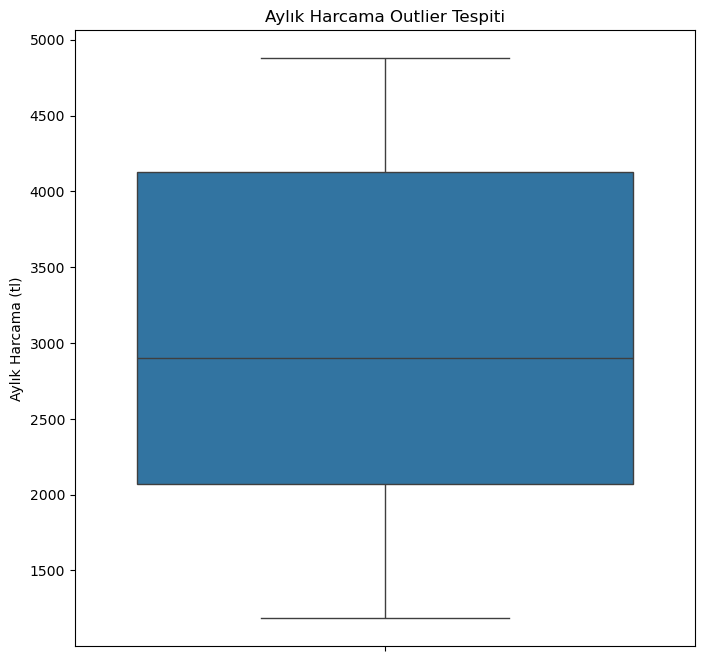

In [9]:
# şimdi de num_spend sütunu için aykırı değer var mı bakacağız. Aykırı değer varsa bu sütundaki boş hücreleri aykırı değere dayanıklı
# olan medyan ile aykırı değer yoksa bu sütundaki boş hücreleri aykırı değere duyarlı olan medyan ile dolduracağız.
# aykırı değer tespiti için hem boxplot hem de iqr yöntemini kullanalım.
plt.figure(figsize=(8,8))
sns.boxplot(
    data=cleaned_df,
    y="marketing_spend"
    )
plt.title("Aylık Harcama Outlier Tespiti")
plt.ylabel("Aylık Harcama (tl)")
plt.show()

In [10]:
# şimdi iqr yöntemini deneyelim.
Q1 = cleaned_df["marketing_spend"].quantile(0.25)
Q3 = cleaned_df["marketing_spend"].quantile(0.75)
IQR = Q3-Q1
lower_bound = (Q1) - (1.5 * IQR) # alt sınır
upper_bound = (Q3) + (1.5 * IQR) # üst sınır
outliers = cleaned_df[(cleaned_df["marketing_spend"] < lower_bound) | (cleaned_df["marketing_spend"] > upper_bound)]
print(f"marketing spend sütunundaki outlier değer sayısı: {len(outliers)}")

marketing spend sütunundaki outlier değer sayısı: 0


- Hem boxplot hemde IQR yöntemi kullanılmış olup, marketing_spend sütunu için aykırı değer tespit edilmemiştir. Bu sütundaki boş hücrelerin ortalama ile doldurulmasına karar verilmiştir.

In [11]:
# marketing_spend sütunundaki boş hücrelerin ortalama ile doldurulma işlemi
marketing_spend_mean = cleaned_df["marketing_spend"].mean()
cleaned_df["marketing_spend"] = cleaned_df["marketing_spend"].fillna(marketing_spend_mean)
# boş hücre kaldı mı kontrol edelim
print(cleaned_df["marketing_spend"].isna().sum())

0


In [12]:
# CAC nedir? toplam satış ve pazarlama giderlerinin kazanılan yeni müşteri sayısına bölünmesiyle elde edilir. Bu sayı bize müşteri edinme maliyetini verir.
# bu sütunu türetiyoruz
cleaned_df["cac"] = cleaned_df["marketing_spend"] / cleaned_df["num_customers"]
cleaned_df.head() # yeni sütuna göz atalım.

,date,sales,marketing_spend,num_customers,discount_rate,cac
0,2022-01-01,9602.000000,2727.78,369,0.18,7.392358
1,2022-02-01,11585.000000,2164.92,450,0.28,4.810933
2,2022-03-01,13258.076211,3447.41,403,0.20,8.554367
3,2022-04-01,13220.000000,1557.98,370,0.27,4.210757
4,2022-05-01,12804.076211,2168.58,314,0.26,6.906306


In [13]:
# şimdide her müşterinin ortalama ne kadar harcadığını türetelim. Bu skorun yüksek olması müşterinin kaliteli olduğunu gösterir.
# bu sütunu toplam harcamayı müşteri sayısına bölerek bulacağız.
cleaned_df["avg_revenue_per_customer"] = cleaned_df["sales"] / cleaned_df["num_customers"]
cleaned_df.head() # yeni sütuna göz atalım.

,date,sales,marketing_spend,num_customers,discount_rate,cac,avg_revenue_per_customer
0,2022-01-01,9602.000000,2727.78,369,0.18,7.392358,26.021680
1,2022-02-01,11585.000000,2164.92,450,0.28,4.810933,25.744444
2,2022-03-01,13258.076211,3447.41,403,0.20,8.554367,32.898452
3,2022-04-01,13220.000000,1557.98,370,0.27,4.210757,35.729730
4,2022-05-01,12804.076211,2168.58,314,0.26,6.906306,40.777313


In [14]:
cleaned_df["date"]=pd.to_datetime(cleaned_df["date"]) # date sütunun str tipinden datetime türüne dönüştürülmesi


In [15]:
print(cleaned_df["date"].dtype) # sütun tipini kontrol edelim.

datetime64[us]


In [16]:
cleaned_df["year"] = cleaned_df["date"].dt.year # zaman serisi analizleri yapabilmek adına year sütununu türetelim.
cleaned_df["month"] = cleaned_df["date"].dt.month # zaman serisi analizleri yapabilmek adına month sütununu türetelim.
cleaned_df.head() # mevcut veri setine göz atalım.

,date,sales,marketing_spend,num_customers,discount_rate,cac,avg_revenue_per_customer,year,month
0,2022-01-01,9602.000000,2727.78,369,0.18,7.392358,26.021680,2022,1
1,2022-02-01,11585.000000,2164.92,450,0.28,4.810933,25.744444,2022,2
2,2022-03-01,13258.076211,3447.41,403,0.20,8.554367,32.898452,2022,3
3,2022-04-01,13220.000000,1557.98,370,0.27,4.210757,35.729730,2022,4
4,2022-05-01,12804.076211,2168.58,314,0.26,6.906306,40.777313,2022,5


In [17]:
from sklearn.model_selection import train_test_split # veri setini train (eğitim) ve test (sınav) olmak üzere 2 gruba ayırıyoruz.
X=cleaned_df[["marketing_spend", "num_customers", "discount_rate", "cac", "avg_revenue_per_customer", "year", "month"]]
y=cleaned_df["sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)


In [18]:
from sklearn.linear_model import LinearRegression # modelimizi kuruyoruz.
model_lr = LinearRegression()
model_lr.fit(X_train, y_train) # modelimizi train verisiyle eğitiyoruz.

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred_lr = model_lr.predict(X_test) # modeli test verisiyle sınava sokuyoruz. Bu soruları daha önce hiç görmedi. Bakalım modelimizin doğruluk oranı nasıl
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr) # modelin doğruluk oranını ölçmek için mae ve r2 metriklerini kullanacağız.

print(f"MAE: {mae:.2f}") # mae:Tahmin edilen değerler ile gerçek değerler arasındaki farkların mutlak değerlerinin ortalamasını alır. 0'a yakın olması istenir; değer ne kadar düşükse model o kadar başarılıdır.
print(f"R2: {r2:.4f}") # r2: Modelinizin bağımsız değişkenler üzerinden bağımlı değişkendeki varyansı (değişkenliği) açıklama yüzdesidir. 

MAE: 1893.59
R2: 0.4687


In [20]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)

y_pred_xgb = model_xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb:.2f}")
print(f"XGBoost R2: {r2_xgb:.4f}")

XGBoost MAE: 1364.30
XGBoost R2: 0.6704


In [22]:
fig = px.line()
fig.add_scatter(x=list(range(len(y_test))), y=y_test.values, name="Gerçek Satışlar", mode="lines+markers")
fig.add_scatter(x=list(range(len(y_test))), y=y_pred_xgb, name="XGBoost Tahmini", mode="lines+markers")
fig.add_scatter(x=list(range(len(y_test))), y=y_pred_lr, name="Linear Regression Tahmini", mode="lines+markers")
fig.update_layout(title="Gerçek vs Tahmin Edilen Satışlar", xaxis_title="Test Gözlemi", yaxis_title="Satış (TL)")
fig.show()

### SONUÇ
Oluşturulan Linear Regression modeli ve 2. model incelendiğinde;
- Linear Regression modeli satışları %47 oranında açıklarken,  XGBoost modeli satışları %67 oranında açıklamaktadır.
- Linear Regression modeli gerçek satışlardan ortalama olarak 1894 tl yanılırken, XGBoost modeli gerçek satışlardan ortalama olarak 1364 tl yanılmaktadır.

Performans metrikleri incelendiğinde şirketimizin performansının iyileştirilmesi açısından XGBoost modeli kullanılmalıdır ancak bu modelde de performans metriklerinin iyileştirilmesi adına satışlar ile bağlantı kurabileceğimiz çeşitli verilerin edinilmesi şirketimizin gelecek satışları tahmin ederken bu modele daha çok güvenmesini sağlayacaktır.